# ADA 25: Exam (100 Points Total)

This exam consists of three tasks. The tasks are independent of each other and can be solved in any order.

A shared "Google Doc" is available here:
- Any announcements will be posted here
- Any questions emailed to <insert email> will appear here

### Random Seed
**Important**: always use the `RANDOM_SEED = 4`, do **NOT** change this

In [1]:
import random
import numpy as np

RANDOM_SEED = 4

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

## Task 1 (40 Points): Good News Can't Wait?

For your first assignment you'll be exploring the conference acceptance process for a top-tier AI conference. Let's start with some background:

**The ICLR Review Process: A Brief Overview:**

The International Conference on Learning Representations (ICLR) is one of the most prestigious AI conferences. It employs a ``double-blind'' peer-review system, meaning the identities of both authors and reviewers are concealed throughout the process. The decision-making workflow generally follows these stages:

1. **Submission & Assignment**: Each paper is typically assigned 3 to 4 independent reviewers based on subject matter expertise, overseen by an Area Chair (AC).
2. **Initial Review Phase**: Reviewers submit independent scores and qualitative feedback.
3. **Discussion & Rebuttal**: Authors can respond to reviews, and reviewers may update their scores based on these discussions.
4. **Recommendation**: The AC synthesizes the reviews and the discussion to provide a Meta-Review and a final recommendation to the Program Chairs.
5. **Final Decision**: The Program Chairs make the ultimate acceptance decision. This is influenced not only by individual paper quality but also by the target acceptance rate for the conference and the total capacity of the venue.

In an effort to promote transparency, ICLR make both the reviews for the accepted **and** the rejected submissions available to the general public.

The ICLR review process is hosted by a website called "Openreview." 
Each paper submission gets its own webpage that shows the paper's title and abstract (short description of the paper) followed by the reviews.
Due to a "quirk" of Openreview, the webpage lists the reviews based on the date they were first posted (the most recent review is shown first). 
For the remainder of this task, we can thus assume the order is "randomly" assigned.
 
**The main focus of this task is to investigate if the order used to present the reviews matters for paper acceptance**

### 1.a: Causal Diagram (5 pts)
From the **AC's point of view**, please describe the causal DAG representing the acceptance recommendation using the following entities:
- paper
- reviews
- order
- AC recommendation

Describe the DAG using equations of the form: A = f(B), C = g(E), etc.  
For each relation, provide a **short** justification.

/Discuss/:

**Answer**
- order = C, _The order is an external, "random", factor_
- reviews = f(paper), _Reviews are only influenced by the paper_
- AC recommendation = f(reviews) + g(paper) + h(order), _The AC takes the reviews, paper, and potentially the order of the reviews into consideration_

### Data task 1 and 2

The data dictionary for task 1 and 2:
- `paper_id`: (str) unique paper ID
- `abstract`: (str) short description of the paper
- `track`: (str) the subject matter category the paper was submitted to
- `r1_score`: (float) the review score shown first
- `r2_score`: (float) the review score shown second
- `r3_score` (float) the review score shown third
- `r4_score`: Optional(float) IF four reviews, the review score shown fourth, ELSE None
- `num_reviews`: (int) the number of reviews the paper received
- `is_accepted`: (int) the final acceptance decision (0 is rejected, 1 is accepted)

In [2]:
# THIS IS THE DATA USED FOR TASK 1 and 2
import pandas as pd

df = pd.read_csv('data/task_1_2_data.csv')
df = df.astype({
    'paper_id': str,
    'abstract': str,
    'track': str,
    'is_accepted': int,
    'r1_score': float,
    'r2_score': float,
    'r3_score': float,
    'r4_score': float,
    'num_reviews': int
    })
df.head()

,paper_id,abstract,track,is_accepted,r1_score,r2_score,r3_score,r4_score,num_reviews
0,zz9jAssrwL,High-performance deep reinforcement learning f...,reinforcement learning,0,3.0,3.0,6.0,NaN,3
1,zyGrziIVdE,The ability to explore efficiently and effecti...,reinforcement learning,0,3.0,3.0,5.0,3.0,4
2,zxg6601zoc,Multimodal instruction tuning has proven to be...,"unsupervised, self-supervised, semi-supervised...",1,6.0,6.0,6.0,5.0,4
3,zxbQLztmwb,There is an open question of what types of num...,interpretability and explainable AI,0,3.0,5.0,6.0,5.0,4
4,zxO4WuVGns,Bayesian observer and actor models have provid...,applications to neuroscience & cognitive science,1,6.0,6.0,6.0,NaN,3


### 1.b Inspect the data (10 pts)
We'll start our investigation with some high-level data analysis:

1. (2 pts) Compute the overall acceptance rate of the conference and print it
2. (2 pts) Compute the average score per paper into a new column `score_avg`
3. (2 pts) Plot a density histogram of these score averages using 20 bins.
4. (2 pts) On a second plot, plot `score_avg` on the x-axis and the acceptance rate on the y-axis. Additionally, add a horizontal line with the overall acceptance rate. Make sure your plot has a clear legend and axes labels.
5. (2 pts) /Discuss/: Based on the two plots, provide score cutoffs for a "clear reject", "clear accept", and "borderline" region

Average acceptance rate: 0.33


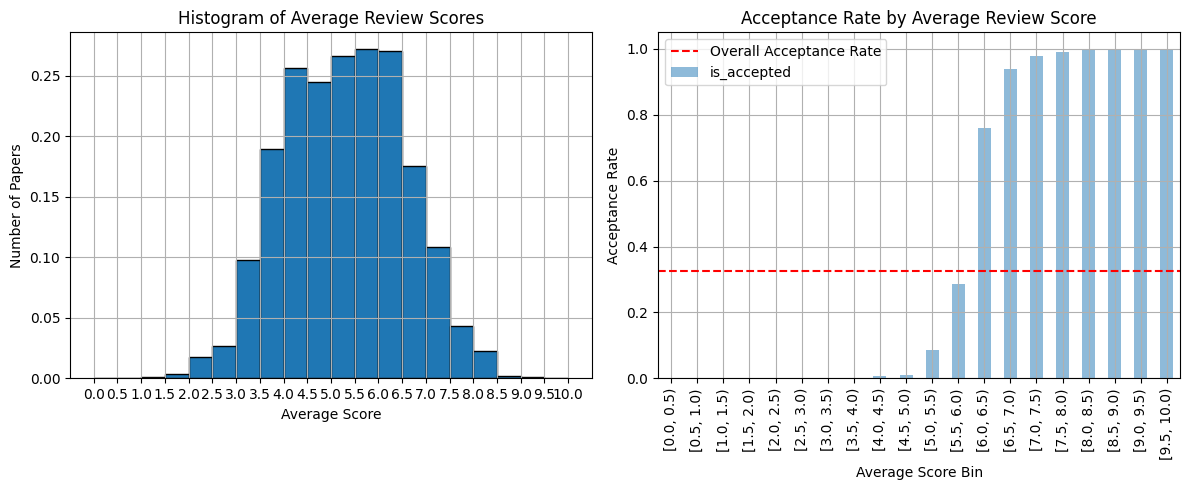

In [3]:
import matplotlib.pyplot as plt
import numpy as np

def score_avg(row):
    scores = [row['r1_score'], row['r2_score'], row['r3_score'], row['r4_score']]
    scores = [s for s in scores if pd.notna(s)]
    if not scores:
        return None
    return sum(scores) / len(scores)

# 1. compute average acceptance rate
avg_acceptance_rate = df['is_accepted'].mean()
print(f"Average acceptance rate: {avg_acceptance_rate:.2f}")

# 2. compute average score
df['score_avg'] = df.apply(score_avg, axis=1)

# 3. bin the average scores in 0.5 increments
bins = np.arange(0, 10.5, 0.5)
df['score_avg_bin'] = pd.cut(df['score_avg'], bins=bins, right=False)
# plot acceptance rate by average score bin
acceptance_rates = df.groupby('score_avg_bin', observed=False)['is_accepted'].mean()

# Create two subplots: histogram and acceptance rate bar plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Histogram of score_avg
df['score_avg'].hist(bins=bins, edgecolor='black', ax=ax1, density=True)
ax1.set_xlabel('Average Score')
ax1.set_ylabel('Number of Papers')
ax1.set_title('Histogram of Average Review Scores')
ax1.grid(True)
ax1.set_xticks(bins)

# Acceptance rate by average score bin
acceptance_rates.plot(kind='bar', alpha=0.5, ax=ax2)
ax2.set_xlabel('Average Score Bin')
ax2.set_ylabel('Acceptance Rate')
ax2.set_title('Acceptance Rate by Average Review Score')
ax2.hlines(avg_acceptance_rate,
           xmin=-0.5,
           xmax=len(acceptance_rates)-0.5,
           color='red', linestyle='--', label='Overall Acceptance Rate')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

**Answer 5**
- [0, 4): clear reject

- [4, 6.5\]: borderline

- (6.5, 10]: clear accept

Note: clear reject ending at 3.5 and clear accept starting at 7 are also fine.

### 1.c. Factors of interest (15 pts)
1. (2 pts) Write a function that checks if the first score is the highest score and add this to the dataframe as new column `is_highest`.
    - Compute and print the average acceptance rate conditioned on the `is_highest` feature.
2. ( 2pts) Write a function that computes the "consensus" of the reviewers measured by **standard deviation multiplied by -1** and adds this to the dataframe as new column `score_consensus`.
    - Compute and print the mean value of `score_consensus` across the dataset.
3. (2 pts) Assume the borderline section starts at 4 and ends at 6.5 (both inclusive).
    - Add a `is_borderline` column and print the average acceptance rate for borderline papers.
4. (4 pts) Use the `logit` function from `statsmodels.formula.api` to perform a logistic regression on the subset of `borderline` papers.
    - `is_accepted` is your target variable
    - `is_highest`, `score_consensus`, `num_reviews`, and `track` are your variables
5. (5 pts) /Discuss/: Based on the results of (4), would you tentatively conclude the effect of review order on the final acceptance decision is significant at 95% CI? How do you interpret the `score_consensus` results?
    - First: compute the Odds Ratio (OR) for the `is_highest` variable, then interpret this value in plain english, e.g., "All things equal, the odds of a paper being accepted are [X] times higher if ..."
    - Second: what might be the relation between `is_highest` and `score_consensus`?


**Hint for 5**: 

_What happens to `is_highest` when there is perfect agreement among reviewers?_
    

In [9]:
def is_highest(row):
    scores = [row['r1_score'], row['r2_score'], row['r3_score'], row['r4_score']]
    scores = [s for s in scores if pd.notna(s)]
    if not scores:
        return None
    return max(scores) == row['r1_score']

def score_consensus(row):
    scores = [row['r1_score'], row['r2_score'], row['r3_score'], row['r4_score']]
    scores = [s for s in scores if pd.notna(s)]
    if not scores:
        return None
    return np.std(scores)

# 1. 
df['is_highest'] = df.apply(is_highest, axis=1)
# 2. 
df['score_consensus'] = -df.apply(score_consensus, axis=1)
# 3. 
df['is_borderline'] = df['score_avg'].apply(lambda x: 4.0 <= x <= 6.5)

print('value counts for is_highest: ', df.is_highest.value_counts(dropna=False))
print('mean of score_consensus: ', df['score_consensus'].mean())
print('average acceptance rate for borderline papers: ', df[df['is_borderline']]['is_accepted'].mean())

import statsmodels.formula.api as smf

# 4.
model = smf.logit("is_accepted ~ is_highest + score_consensus + num_reviews + C(track)", 
                  data=df[df['is_borderline']]).fit()

print(model.summary())

value counts for is_highest:  is_highest
False    4831
True     4636
Name: count, dtype: int64
mean of score_consensus:  -1.0068189038450346
average acceptance rate for borderline papers:  0.28659268146370726
Optimization terminated successfully.
         Current function value: 0.583492
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:            is_accepted   No. Observations:                 6668
Model:                          Logit   Df Residuals:                     6644
Method:                           MLE   Df Model:                           23
Date:                Tue, 13 Jan 2026   Pseudo R-squ.:                 0.02601
Time:                        17:39:58   Log-Likelihood:                -3890.7
converged:                       True   LL-Null:                       -3994.6
Covariance Type:            nonrobust   LLR p-value:                 1.057e-31
                                                         

**Answer 5**:

`is_highest`:
- The Odds Ratio is $e^{-0.023} \approx 0.98$, meaning the odds of a paper being accepted are approximately 0.98x lower (a decrease of 2%) when the first review is the highest score, compared to when it is not.
- The p-value is 0.69, so the `is_highest` variable is **not** statistically significant

`score_consensus`:
- The `score_consensus` is statistically significant, meaning that the less reviewers disagree, the more likely acceptance.
- If `score_consensus` is perfect, all scores are the same. This means `is_highest` is always true, thus entangling the analysis

Based on these results alone, you would conclude that `is_highest` has no statistically significant effects on the acceptance.


### 1.d Statistical Twins (10 pts)
To truly isolate the impact of the position of a review (the "champion" effect) from the quality of the paper, we use a matching strategy. By grouping papers into "Statistical Twins"—papers that received the exact same set of scores (e.g., three reviewers all gave a 5, 6, and 8)—we effectively hold paper quality constant. Within these identical sets, we can then ask: Does the specific behavior or timing of the 'highest' reviewer (the 8) change the outcome, even when the `signature` of the paper is identical? This approach mimics a controlled experiment, allowing us to see if the Area Chair is influenced by how a score sits within the distribution, rather than just the raw scores themselves.

1. (2 pts) Write a function that adds a review sore `signature` column. That is: the set of scores a paper received.
2. (2 pts) Filter out any non-borderline papers and any signatures that have fewer than 10 papers.
3. (4 pts) Perform an appropriate statistical test and report the p-value
4. (2 pts) /Discuss:/ What do you conclude at 95% CI?

In [10]:
from scipy import stats

def get_signature(row):
    scores = [row['r1_score'], row['r2_score'], row['r3_score'], row['r4_score']]
    return str(set(scores))

# 1. compute signature
df['signature'] = df.apply(get_signature, axis=1)

# 2. Filter for Borderline & Frequent Signatures
df_ = df[df['is_borderline']].copy()
common_sigs = df_['signature'].value_counts()[lambda x: x >= 10].index
df_twin = df_[df_['signature'].isin(common_sigs)].copy()

# 3. Aggregation
# We calculate acceptance rate for "is_highest" or not for EACH signature
twins = df_twin.pivot_table(index='signature', columns='is_highest', values='is_accepted', aggfunc='mean')

# Drop signatures where we don't have comparison data (both True and False columns must exist)
twins = twins.dropna()

# Paired Test
# One of paired tests: Wilcoxon signed-rank test or Paired t-test
stat, p_val = stats.wilcoxon(twins[True], twins[False])
# stat, p_val = stats.ttest_rel(twins[True], twins[False])

print(f"Paired Difference (Bias): {(twins[True] - twins[False]).mean():.3f}")
print(f"P-Value for Anchoring: {p_val:.4f}")

Paired Difference (Bias): 0.021
P-Value for Anchoring: 0.2364


**Answer, 4**: The ordering is not of causal relevance

## Task 2 (20 Points): You had me at Hello

While numerical scores and review order provide a structural view of the conference, the content of the research itself—expressed through the abstract contains the actual "signal" of innovation. In this section, we shift from review metadata to Natural Language Processing (NLP). Research papers often follow linguistic trends; certain methodologies (e.g., "diffusion models," "transformers") or buzzwords may be associated with higher acceptance rates in a given year.

### 2.a Buzzz words (10 pts)
1. (3 pts) Use `sklearn.feature_extraction.text.TfidfVectorizer` to transform the abstract column into a feature matrix $X$
    - Constraint 1: Remove English stop words to discard uninformative frequent terms.
    - Constraint 2: Use both unigrams (1-gram) and bigrams (2-gram) to capture phrases like "neural network".
    - Constraint 3: Limit max_features to 2,000 to avoid creating a matrix that is too sparse or high-dimensional.
2. (2 pts) Fit a Logistic Regression model (`sklearn.linear_model.LogisticRegression`) to predict is_accepted using the TF-IDF matrix.
    - You must use L2 (Ridge) or L1 (Lasso) regularization to penalize large weights, as text data often has more features than documents ($D > N$) which leads to overfitting.
3. (3 pts) Extract the model coefficients ($\beta$) and list the top 10 words (features) with the highest positive coefficients and the top 5 words with the lowest negative coefficients.

Once a paper is accepted, authors are asked to provide a _camera-ready_ version. This means authors can update their paper, which can also change the abstract.

4. (2 pts) /Discuss/: Carefully examine the top words for the rejected and accepted papers:
    - If your goal was to help an author predict if their paper would be accepted based only on the abstract, why is this current model "useless"?


**Hint, 4**:

_Use your knowledge of the double-blind review policy (where the identity of the authors and reviewers should remain anonymous)_

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import numpy as np

# 1. Setup Vectorizer
vectorizer = TfidfVectorizer(
    stop_words='english', 
    max_features=2000, 
    ngram_range=(1, 2),
)

# 2. Transform
X_text = vectorizer.fit_transform(df['abstract'].fillna(''))
y = df['is_accepted']

# 3. Fit Model with Regularization
model = LogisticRegression(l1_ratio=0, C=1.0, solver='liblinear')
model.fit(X_text, y)

# 4. Extract Top Words
feature_names = vectorizer.get_feature_names_out()
coefs = model.coef_[0]

# Sort indices
sorted_indices = np.argsort(coefs)

print("Words associated with Rejection:", feature_names[sorted_indices[:10]])
print("Words associated with Acceptance:", feature_names[sorted_indices[-10:]])

Words associated with Rejection: ['anonymous' 'https anonymous' 'anonymous 4open' '4open' '4open science'
 'domain' 'textit' 'science' 'paper' 'addressing']
Words associated with Acceptance: ['code available' 'project' 'io' 'github io' 'available https' 'https'
 'com' 'https github' 'github com' 'github']


**Answer, 4**: There is clear label leakage as the rejected papers still have the anonymized abstracts but the accepted papers have de-anonymzed links

### 2.b Topics Matter? (10 pts)
Individual keywords are often noisy and can be influenced by formatting or procedural artifacts. To capture the underlying research themes of the ICLR corpus, we must shift our analysis from vocabulary to latent concepts.

1. (3 pts) Use TruncatedSVD (Latent Semantic Analysis) to factorize your TF-IDF matrix into 50 latent components, ensuring you set random_state=RANDOM_SEED.
    - Identify the Theme: Extract and print the top 10 words associated with the second component (index 1).
    - **Mathematical Context**: _This process approximates the decomposition $T \approx USV^T$. By analyzing the components, we are examining the "Topic Space" where words that frequently co-occur are grouped into singular axes of variance._

2. (3 pts) Create a new column in your dataframe called `topic_1_strength` using the values from this second component. Generate a scatter plot with a linear regression trend line to visualize the relationship between a paper's alignment with this topic and its `score_avg`.

3. (4 pts) Calculate the Pearson correlation coefficient ($r$) and its associated p-value.
    - /Discuss/: Based on your p-value, is the relationship between this topic and review scores statistically significant at the $\alpha = 0.05$ level?
    - /Discuss/: Examine the magnitude of the correlation coefficient. In the context of a competitive peer-review process, how much of the variance in scores is actually explained by a paper’s alignment with this dominant topic? Contrast the statistical significance with the practical meaningfulness of this effect.

Topic 1 Top Words: ['large' 'human' 'models llms' 'models' 'large language' 'language models'
 'llm' 'language' 'reasoning' 'llms']


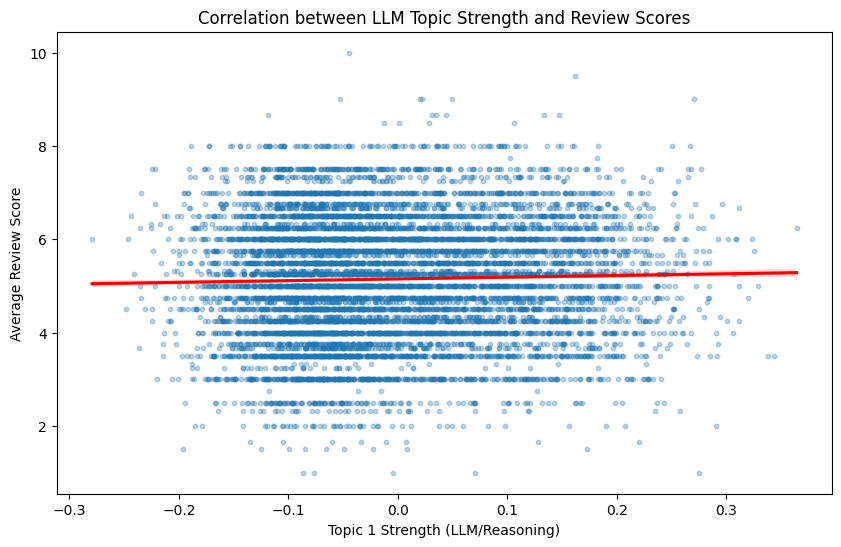

Pearson Correlation: 0.029
P-value: 4.6573e-03


In [ ]:
import seaborn as sns
from scipy import stats
from sklearn.decomposition import TruncatedSVD

# 1. Fit LSA with 10 components
svd = TruncatedSVD(n_components=50, random_state=RANDOM_SEED)
X_lsa = svd.fit_transform(X_text)

# components_ has shape (n_components, n_features)
topic_1_weights = svd.components_[1] 
feature_names = vectorizer.get_feature_names_out()

# Get indices of top 5 words
top_indices = np.argsort(topic_1_weights)[-10:]
top_words = feature_names[top_indices]
print(f"Topic 1 Top Words: {top_words}")

# 2. Scatter Plot of Topic Strength vs. Average Score
df['topic_1_strength'] = X_lsa[:, 1]
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df, 
    x='topic_1_strength', 
    y='score_avg', 
    scatter_kws={'alpha': 0.3, 's': 10}, # Make points transparent to handle overplotting
    line_kws={'color': 'red'}            # Make the trend line stand out
)

plt.title(f"Correlation between LLM Topic Strength and Review Scores")
plt.xlabel("Topic 1 Strength (LLM/Reasoning)")
plt.ylabel("Average Review Score")
plt.show()

# 3. The "Hype" Test
res = stats.pearsonr(df['topic_1_strength'], df['score_avg'])
print(f"Pearson Correlation: {res.statistic:.3f}")
print(f"P-value: {res.pvalue:.4e}")


**Answer, 3**:
- The effect is significant at the 95% CI level
- The effect size however is very small, r of 0.03, meaning it explains less than 0.1% of the variance in review score ($r^2 \approx 0.0008$)

## Task 3 (40 Points): Minds of a Matter Publish Together

In the final stage of our analysis, we move beyond the text of the paper and the mechanics of the review process to examine the social topology of the ICLR community. Science is rarely a solitary endeavor; it is conducted within a network of collaborators, laboratories, and institutions.

In this section, you will treat the conference as a Co-authorship Network. By representing authors as nodes and their collaborations as edges, you will investigate whether the "connectedness" of an author—their position within the global research web—relates to the likelihood of their work being accepted. Is acceptance purely a meritocracy of ideas, or do structural advantages within the social graph play a role in the "minds of a matter" publishing together?

### Data task 3

The data dictionary for task 3:
- `paper_id`: (str) unique paper ID
- `authorids`: (list[str]) the unique IDs of authors listed on a paper
- `is_accepted`: (int) the final acceptance decision (0 is rejected, 1 is accepted)

In [ ]:
import pandas as pd

df_papers = pd.read_csv('data/task_3_data.csv')
df_papers['authorids'] = df_papers['authorids'].apply(eval)
df_papers.head()

,paper_id,authorids,is_accepted
0,zzk231Ms1Ih,"[~Arun_Rajkumar4, ~Vishnu_Veerathu1, cs20d400@...",1
1,zz9hXVhf40,"[~Cong_Lu1, ~Philip_Ball1, ~Jack_Parker-Holder...",1
2,zyrhwrd9EYs,"[~Jeroen_Berrevoets1, ~Fergus_Imrie1, ~Trent_K...",0
3,zxEfpcmTDnF,"[~Samir_Alain_Sadok1, ~Simon_Leglaive1, lauren...",0
4,zuqcmNVK4c2,"[~Navid_Kardan1, ~Mubarak_Shah3, ~Mitch_Hill1]",1


### 3.a: Preparing the data (8pts)
1. (2 pts) /Discuss/: We have removed all papers that had more than 13 authors (<1% of the papers). Why might we do this?
2. (2 pts) /Discuss/: We also want to exclude all authors that have fewer than 3 paper from this analysis. Why?
3. (2 pts) Use the data to create an undirected graph where authors are nodes and edged indicate collaboration on a paper.
4. (2 pts) Print the total number of nodes and edges

**important**: Only include authors that have at least 3 papers.

**Answer, 1 and 2**:
1. Papers with many authors form large cliques (fully connected subgraphs) that artificially inflate edge counts and distort network metrics like degree centrality and clustering coefficients, skewing the analysis of typical collaboration patterns.
2. To ensure the "acceptance rate" metric is statistically reliable (rates based on 1 or 2 papers are highly noisy) and to focus the analysis on the active, stable core of the research community rather than transient participants.

In [ ]:
import networkx as nx
import itertools
from collections import defaultdict

# 1.
MIN_NUM_PAPERS = 2
author_to_papernum = defaultdict(int)

for author_ids in df_papers['authorids']:
    for author_id in author_ids:
        author_to_papernum[author_id] += 1
included_authors = {author: num_papers > MIN_NUM_PAPERS for author, num_papers in author_to_papernum.items()}
G = nx.Graph()

for author_ids in df_papers['authorids']:
    filtered_author_ids = [author_id for author_id in author_ids if included_authors.get(author_id, False)]
    if len(filtered_author_ids) < 2:
        continue
    edges = list(itertools.combinations(filtered_author_ids, 2))
    G.add_edges_from(edges)
    G.add_nodes_from(filtered_author_ids)
    
# 2.
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")    

Number of nodes: 11865
Number of edges: 66559


### 3.b: Network Feature Engineering (12 pts)
To understand what drives success, we must move beyond simple counts (like number of papers) and quantify an author's structural position. Are they a "hub" connected to many? Are they "influential" by connecting to other key players? Or are they stuck in a tight "clique"? We will create features to measure these distinct properties.

#### 3.b.1: Network Metrics (6 pts)
1. (2 pts) Plot the degree distribution using a log plot.
    - /Discuss/: Does this network follow a power-law distribution?

2. (2 pts) Use the network graph you created to compute the following network metrics for each author: degree, pagerank, cluster coefficient

3. (2 pts) Create a dataframe called `df_features_network` that has the columns: "author_id", "degree", "pagerank", "cluster_coeff" and print the first five rows


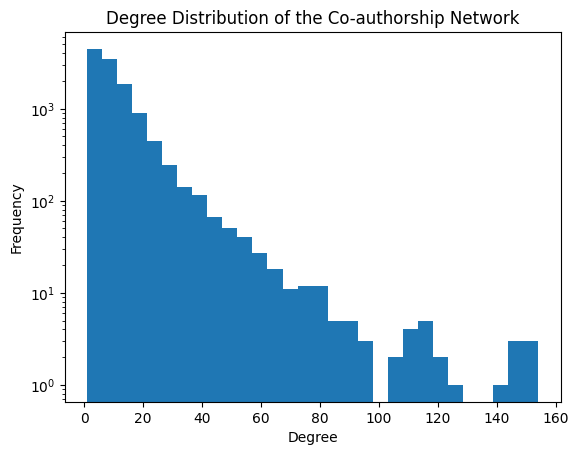

,author_id,degree,pagerank,cluster_coeff
0,~Cong_Lu1,3,0.000035,0.000000
1,~Jack_Parker-Holder1,20,0.000134,0.315789
2,~Jeroen_Berrevoets1,10,0.000096,0.511111
3,~Fergus_Imrie1,14,0.000126,0.373626
4,~Mihaela_van_der_Schaar2,33,0.000294,0.145833


In [ ]:
# 1.
degrees = list(dict(G.degree()).values())
plt.hist(degrees, bins=30, log=True)
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.title("Degree Distribution of the Co-authorship Network")
plt.show()

# Yes, the observed straight line represents a power-law distribution!

# 2.
author_to_degree = dict(G.degree())
author_to_pagerank = nx.pagerank(G)
author_to_cluster_coeff = nx.clustering(G)

# 3.
df_features_network = pd.DataFrame({
    "author_id": list(author_to_degree.keys()),
    "degree": [author_to_degree[author] for author in author_to_degree.keys()],
    "pagerank": [author_to_pagerank[author] for author in author_to_degree.keys()],
    "cluster_coeff": [author_to_cluster_coeff[author] for author in author_to_degree.keys()]
    })

df_features_network.head()

#### 3.b.2: Paper Metrics (6 pts)

Use the original `df_papers` dataframe to create a new dataframe called `df_features_author` that contains the following collumns:
1. `author_id`
2. `number_of_papers`, the number of papers the author wrote
3. `average_num_collaborators`, the average number of collaborators (other authors) per paper
4. `acceptance_rate`, the average acceptance probabilty of `is_accepted` across papers

Please print the first 5 rows.

In [ ]:
author_to_outcomes = defaultdict(list)
author_to_num_collaborators_per_paper = defaultdict(list)

for i, paper in df_papers.iterrows():
    for author_id in paper["authorids"]:
        author_to_outcomes[author_id].append(paper['is_accepted'])
        author_to_num_collaborators_per_paper[author_id].append(len(paper["authorids"]) - 1)

df_features_author = pd.DataFrame({
    "author_id": list(author_to_outcomes.keys()),
    "acceptance_rate": [np.mean(outcomes) for outcomes in author_to_outcomes.values()],
    "number_of_papers": [len(outcomes) for outcomes in author_to_outcomes.values()],
    "collaborators_per_paper": [np.mean(author_to_num_collaborators_per_paper[author]) for author in author_to_outcomes.keys()]
    })
df_features_author.head()

,author_id,acceptance_rate,number_of_papers,collaborators_per_paper
0,~Arun_Rajkumar4,0.25,4,2.0
1,~Vishnu_Veerathu1,1.00,1,2.0
2,cs20d400@smail.iitm.ac.in,1.00,1,2.0
3,~Cong_Lu1,0.75,4,2.5
4,~Philip_Ball1,1.00,1,4.0


### 3.c Analysis (10 pts)
The average acceptance rate for top conferences often lies around 33%. We could therefore classify "successful authors" as those with an acceptance rate of >40%.
1. (2 pts) First merge `df_features_network` and `df_features_author` using an `inner` merge operation to create `df_features` 
2. (2 pts) Add a new column to your dataframe for successful authors called `is_successful` using the rule `acceptance_rate` > 0.4
3. (3 pts) Compute the correlations of the features with respect to the `is_successful` column. Additionally, perform a groupby on `is_successful` with respect to the features printing the mean and standard errors.
4. (3 pts) /Discuss/:  Observe the correlations for `degree` and `cluster_coeff`. Using the "structural holes" theory, how could one interpret these results?

In [ ]:
# 1.
df_features = df_features_network.merge(
    df_features_author, on='author_id', how='inner'
    )

# 2.
df_features["is_successful"] = df_features["acceptance_rate"] > 0.4

# 3.
features = ['number_of_papers', 'collaborators_per_paper', 'degree', 'pagerank', 'cluster_coeff']
target = 'is_successful'
cols = features + [target]
correlations = df_features[cols].corr()["is_successful"].sort_values(ascending=False)
print('correlations with is_successful:')
print(correlations)

print("\nGroup-wise statistics:")
df_features.groupby(target)[features].agg(['mean', 'sem'])

correlations with is_successful:
is_successful              1.000000
degree                     0.113283
pagerank                   0.093429
number_of_papers           0.056338
collaborators_per_paper    0.041198
cluster_coeff             -0.076504
Name: is_successful, dtype: float64

Group-wise statistics:


number_of_papers           collaborators_per_paper            \
                          mean       sem                    mean       sem   
is_successful                                                                
False                 5.745318  0.061398                4.863121  0.019425   
True                  6.419458  0.097760                5.006211  0.025187   

                  degree            pagerank               cluster_coeff  \
                    mean       sem      mean           sem          mean   
is_successful                                                              
False          10.249064  0.118092  0.000080  6.222272e-07      0.526447   
True           12.872180  0.188513  0.000091  1.006736e-06      0.481787   

                        
                   sem  
is_successful           
False          0.00337  
True           0.00396

**Answer, 4**: While `degree` positively correlates with being successful, the `cluster_coef` has a negative correlation. This supports the "Structural Holes" theory in which authors in tightly clustered cliques (where everyone knows everyone) may be exposed to redundant information. In contrast, authors with lower clustering likely act as "bridges" between different communities, gving them access to novel ideas and diverse perspectives, which correlates with higher acceptance rates.

### 3.d Prediction (10 pts)
We have seen some interesting correlations in the previous question. Let's see if we can use this to "predict" if a paper will be accepted!
1. (2 pts) Create three new column in the df_papers dataframe: `avg_degree, avg_pagerank, avg_cluster_coeff`. Populate these by calculating the "mean" of the respective metrics for all **active authors** on that paper (these should be the ones in the `df_features` dataframe!).
2. (1 pts) Define `X` as the features data using the three new features and `y` as the `is_accepted` column
3. (1 pts) Split the data into 80% training and 20% testing sets using `random_state=RANDOM_SEED`
4. (1 pts) Train a `LogisticRegression` classifier on the training set
5. (1 pts) Predict the `y` for the test set
6. (2 pts) Print the accuracy score and print the `Coefficients` of the model to identify which network feature is the strongest predictor of acceptance
7. (2 pts) /Discuss/: Given that the average baseline acceptance rate is ~33%, do the network features provide a meaningful signal for predicting paper acceptance?

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Feature Engineering: Create paper-level features
# Helper to look up author stats and calculate the mean
lookup_dict = {d["author_id"]: d for d in df_features.to_dict('records')}

def get_avg_stats(author_list):
    # Select the relevant columns from the author features dataframe
    degree_stats = []
    pagerank_stats = []
    cluster_coeff_stats = []
    for author_id in author_list:
        stats = lookup_dict.get(author_id)
        if stats:
            degree_stats.append(stats['degree'])
            pagerank_stats.append(stats['pagerank'])
            cluster_coeff_stats.append(stats['cluster_coeff'])
    stats = pd.Series({
        'avg_degree': np.mean(degree_stats) if degree_stats else 0,
        'avg_pagerank': np.mean(pagerank_stats) if pagerank_stats else 0,
        'avg_cluster_coeff': np.mean(cluster_coeff_stats) if cluster_coeff_stats else 0
    })
    return stats

# Apply the function to the 'author_ids' column
paper_stats = df_papers['authorids'].apply(get_avg_stats)
df_papers[['avg_degree', 'avg_pagerank', 'avg_cluster_coeff']] = paper_stats

# 2. Define X and y
X = df_papers[['avg_degree', 'avg_pagerank', 'avg_cluster_coeff']]
y = df_papers['is_accepted'].astype(int)

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

# 4. Train Model
clf = LogisticRegression()
clf.fit(X_train, y_train)

# 5. Predict
y_pred = clf.predict(X_test)

# 6. Evaluation
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")

# Display coefficients with feature names
coeffs = pd.DataFrame(clf.coef_.T, index=X.columns, columns=['Coefficient'])
print(coeffs)


Accuracy Score: 0.6710
                   Coefficient
avg_degree            0.017760
avg_pagerank          0.000026
avg_cluster_coeff     0.474284


**Answer, 7**: No, the chance of being accepted is ~33%, so the chance of being rejected is ~67%. Hence, by simply always predicting rejection you would obtain an accuracy of 67%.